In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hamsim import hamiltonian, evolution

** Trotter error converges at the expected first-order rate, and
   within the theoretical commutator bound.**

For a first-order product formula, Lloyd (1996)	bounds the error by

$$ \vert\vert U - U_{\rm trott} \vert\vert \leq (t^2 / 2n)
\sum_{i<j} \vert\vert[H_i, H_j ] \vert\vert $$

where $U = e^{-iHt}$ is the exact evolution operator, and 
$U_{\rm trott} = (e^{-iH_1t/n} \cdots e^{-iH_lt/n})^n$ is the $n$-step 
Trotter product. The measured error tracks the bound's scaling closely; 
both curves are parallel on a log-log plot, confirming the correct 
first-order convergence rate and the true error sits consistently below 
the bound across the full range of step counts tested.

<!-- ![Trotter error vs. theoretical bound](docs/figures/error_scaling.png)

Each local operator $e^{-iH_it/n}$ acts on a Hilbert 
space of only $m=4$ dimensions (two neighboring qubits), rather that the
full $2^N$ dimensional space of the whole system of N qubits in the full
hilbert space in $H$. This locality is what the efficient implementation exploits
directly, via tensor contraction rather than dense matrix exponentiation. -->

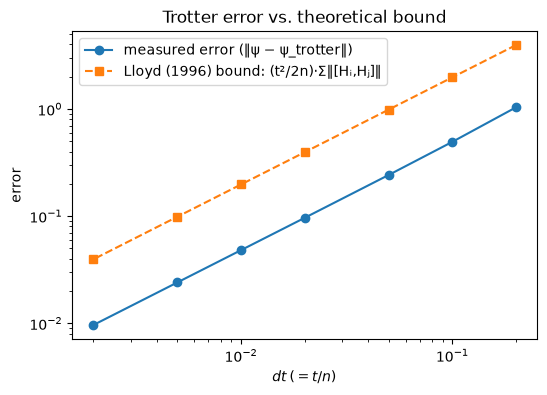

In [4]:
N = 3
H = hamiltonian.ising(n=N)
Hi = hamiltonian.ising_trotter(n=N)

psi0 = np.zeros(2**N, dtype=complex); psi0[1] = 1  # |001>
t_final = 1

step_counts = [5, 10, 20, 50, 100, 200, 500]
dts = t_final / np.array(step_counts)

bounds = [
    evolution.trotter_error_bound(Hi, t_final, n) for n in step_counts
]
true_errors = [
    evolution.trotter_true_error(H, Hi, psi0, t_final, n) for n in step_counts
]

fig, ax = plt.subplots(figsize=(6,4))
ax.loglog(dts, true_errors, 'o-', label="measured error (‖ψ − ψ_trotter‖)")
ax.loglog(dts, bounds, 's--', label="Lloyd (1996) bound: (t²/2n)·Σ‖[Hᵢ,Hⱼ]‖")
ax.set_xlabel(r"$dt \: \left( =t/n \right)$")
ax.set_ylabel("error")
ax.legend()
ax.set_title("Trotter error vs. theoretical bound")
plt.show
fig.savefig('../docs/figures/error_scaling.png', dpi=150, bbox_inches='tight')